In [1]:
import pandas as pd
import numpy as np

In [3]:
cd D:\Shailja Data\DS\time series

D:\Shailja Data\DS\time series


In [5]:
df= pd.read_csv("data.csv")
df

C:\Users\vasmi\AppData\Local\Temp\ipykernel_29760\4129590069.py:1: DtypeWarning: Columns (28,37,38) have mixed types. Specify dtype option on import or set low_memory=False.
  df= pd.read_csv("data.csv")


,ID,Country,VFN,Mp,Mh,Man,MMS,Tan,T,Va,...,Erwltp (g/km),De,Vf,Status,year,Date of registration,Fuel consumption,ech,RLFI,Electric range (km)
0,80699376,DE,IP-2020_2414-W1K-1,MERCEDES-BENZ,MERCEDES-BENZ AG,MERCEDES-BENZ AG,NaN,e1*2007/46*1912*13,F2CLA,3310T2,...,1.0,NaN,NaN,P,2022,2022-01-18,5.1,NaN,NaN,NaN
1,80699377,DE,IP-2020_2413-W1K-1,MERCEDES-BENZ,MERCEDES-BENZ AG,MERCEDES-BENZ AG,NaN,e1*2007/46*1912*13,F2CLA,3310T2,...,1.0,NaN,NaN,P,2022,2022-01-06,4.9,NaN,NaN,NaN
2,80699378,DE,IP-2020_2413-W1K-1,MERCEDES-BENZ,MERCEDES-BENZ AG,MERCEDES-BENZ AG,NaN,e1*2007/46*1912*13,F2CLA,3310T2,...,1.0,NaN,NaN,P,2022,2022-01-13,4.9,NaN,NaN,NaN
3,80699379,DE,IP-2020_2414-W1K-1,MERCEDES-BENZ,MERCEDES-BENZ AG,MERCEDES-BENZ AG,NaN,e1*2007/46*1912*13,F2CLA,3310T2,...,1.0,NaN,NaN,P,2022,2022-02-10,5.4,NaN,NaN,NaN
4,80699380,DE,IP-2020_2414-W1K-1,MERCEDES-BENZ,MERCEDES-BENZ AG,MERCEDES-BENZ AG,NaN,e1*2007/46*1912*13,F2CLA,3310T2,...,1.0,NaN,NaN,P,2022,2022-03-01,5.1,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
781294,152291964,DE,IP-2023_4026-W1K,MERCEDES-BENZ AG,MERCEDES-BENZ AG,MERCEDES-BENZ AG,NaN,e1*2007/46*1909*27,F2B,OYERZ1,...,NaN,NaN,NaN,P,2024,2024-09-26,NaN,AX,RL-2023_0015-W1K,415.0
781295,152291967,DE,IP-2023_0401-W1K,MERCEDES-BENZ AG,MERCEDES-BENZ AG,MERCEDES-BENZ AG,NaN,e1*2018/858*00186*05,R2CGLC,837PTB,...,NaN,NaN,NaN,P,2024,2024-11-13,7.5,EURO 6 EA,RL-2022_0055-W1K,12.0
781296,152291974,DE,IP-HC11_A_2022_1-HES-1,MERCEDES-BENZ AG,SMART,SMART AUTOMOBILE CO LTD,NaN,e1*2018/858*00349*01,HC11,0000,...,NaN,NaN,NaN,P,2024,2024-04-26,NaN,AX,RL-HC11_A_2022-HES-1,435.0
781297,152291977,DE,IP-2019_2610-WDB-1,MERCEDES-BENZ AG,MERCEDES-BENZ AG,MERCEDES-BENZ AG,NaN,e1*2007/46*1885*17,H1GLE,B223T1,...,1.1,NaN,NaN,P,2024,2024-01-04,8.3,EURO 6 AP,RL-2018_0090-WDB-1,NaN


In [7]:

import matplotlib.pyplot as plt

# 1. Load Data

df['Date of registration'] = pd.to_datetime(df['Date of registration'])

# 2. Handling the NaNs in Ewltp (g/km)
# Instead of a simple mean, I used a 'Grouped Imputation' 
# This is more accurate: filling Nulls with the average of their specific vehicle type (Tan)
df['Ewltp (g/km)'] = df.groupby('Tan')['Ewltp (g/km)'].transform(lambda x: x.fillna(x.mean()))

# 3. Feature Engineering: The "Euro 7 Risk Score"
# Heavier vehicles have harder times with Cold Start emissions.
# proxy for 'Risk' based on Mass (m kg) and current Ewltp
# High Risk = Above 75th percentile in Mass OR Ewltp
mass_threshold = df['m (kg)'].quantile(0.75)
ewltp_threshold = df['Ewltp (g/km)'].quantile(0.75)

df['Euro7_Risk_Level'] = np.where(
    (df['m (kg)'] > mass_threshold) | (df['Ewltp (g/km)'] > ewltp_threshold), 
    'High Risk', 'Standard'
)

# 4. Creating the Time-Series (Monthly Aggregation)
# We aggregate by month to see how the fleet's average CO2 is moving
fleet_timeseries = df.set_index('Date of registration').resample('ME').agg({
    'Ewltp (g/km)': 'mean',
    'm (kg)': 'mean',
    'ID': 'count' # This gives us registration volume
}).rename(columns={'ID': 'Registration_Volume'})

print("--- Monthly Fleet Summary ---")
print(fleet_timeseries.head())

--- Monthly Fleet Summary ---
                      Ewltp (g/km)       m (kg)  Registration_Volume
Date of registration                                                
2022-01-31              122.603607  1847.213725                19352
2022-02-28              115.719943  1874.853057                19089
2022-03-31              121.302511  1862.485929                21143
2022-04-30              123.067010  1876.790227                16699
2022-05-31              130.202793  1869.900404                18334


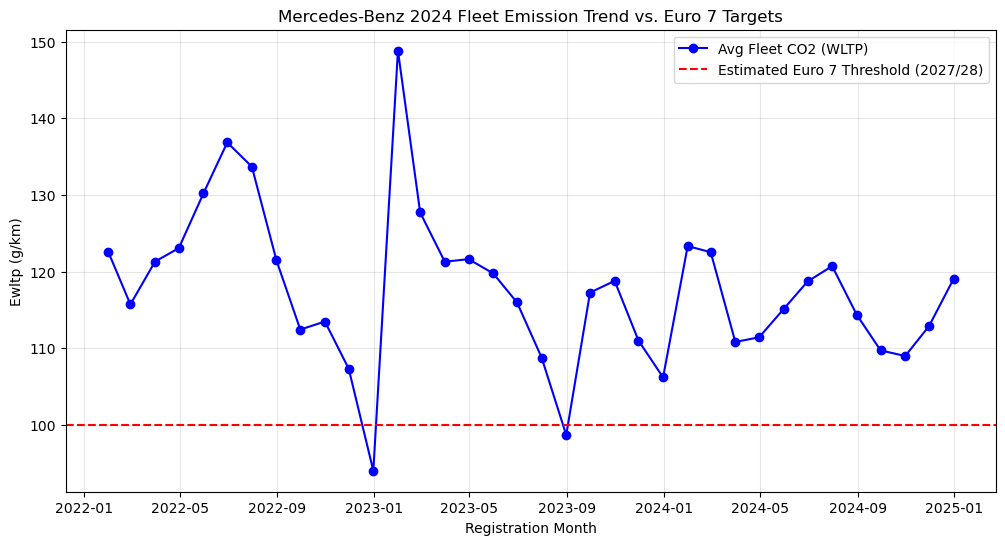

In [9]:
plt.figure(figsize=(12, 6))
plt.plot(fleet_timeseries.index, fleet_timeseries['Ewltp (g/km)'], marker='o', linestyle='-', color='blue', label='Avg Fleet CO2 (WLTP)')

# Add a "Target Line" for Euro 7 (Simulation)
# Suppose Euro 7 requires a 15% reduction from current average
target_limit = fleet_timeseries['Ewltp (g/km)'].mean() * 0.85
plt.axhline(y=target_limit, color='red', linestyle='--', label='Estimated Euro 7 Threshold (2027/28)')

plt.title('Mercedes-Benz 2024 Fleet Emission Trend vs. Euro 7 Targets')
plt.xlabel('Registration Month')
plt.ylabel('Ewltp (g/km)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

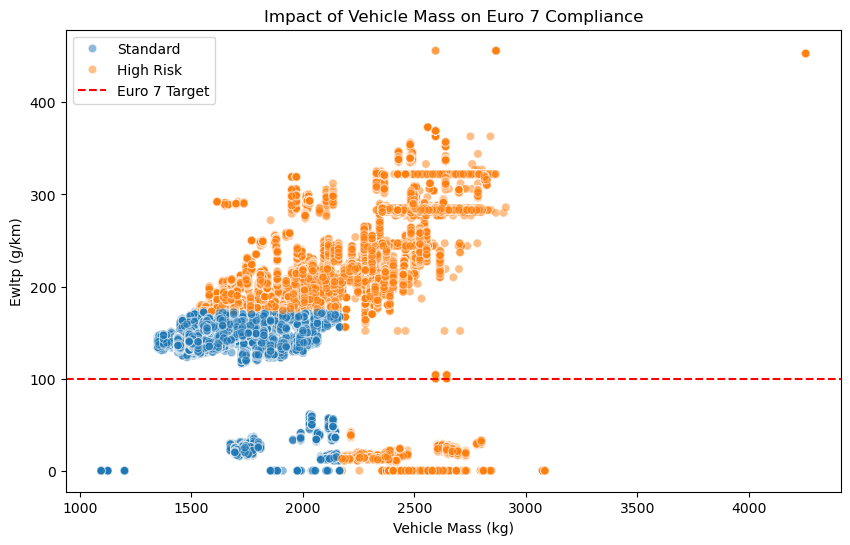

Correlation between Mass and Emissions: -0.01


In [25]:
import seaborn as sns

# 1. Scatter Plot: Mass vs. CO2
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='m (kg)', y='Ewltp (g/km)', hue='Euro7_Risk_Level', alpha=0.5)

# Euro 7 Target line (horizontal)
plt.axhline(y=target_limit, color='red', linestyle='--', label='Euro 7 Target')

plt.title('Impact of Vehicle Mass on Euro 7 Compliance')
plt.xlabel('Vehicle Mass (kg)')
plt.ylabel('Ewltp (g/km)')
plt.legend()
plt.show()

# 2. Correlation Strength
correlation = df[['m (kg)', 'Ewltp (g/km)']].corr().iloc[0,1]
print(f"Correlation between Mass and Emissions: {correlation:.2f}")

In [21]:
df.columns

Index(['ID', 'Country', 'VFN', 'Mp', 'Mh', 'Man', 'MMS', 'Tan', 'T', 'Va',
       'Ve', 'Mk', 'Cn', 'Ct', 'Cr', 'r', 'm (kg)', 'Mt', 'Enedc (g/km)',
       'Ewltp (g/km)', 'W (mm)', 'At1 (mm)', 'At2 (mm)', 'Ft', 'Fm',
       'ec (cm3)', 'ep (KW)', 'z (Wh/km)', 'IT', 'Ernedc (g/km)',
       'Erwltp (g/km)', 'De', 'Vf', 'Status', 'year', 'Date of registration',
       'Fuel consumption ', 'ech', 'RLFI', 'Electric range (km)',
       'Euro7_Risk_Level'],
      dtype='object')

In [33]:
petrol_df.isnull().sum()

ID                           0
Country                      0
VFN                         24
Mp                           0
Mh                           0
Man                          0
MMS                     167509
Tan                         20
T                            0
Va                          21
Ve                          22
Mk                           0
Cn                           0
Ct                           0
Cr                           0
r                            0
m (kg)                       0
Mt                          27
Enedc (g/km)            167509
Ewltp (g/km)                20
W (mm)                  167509
At1 (mm)                167509
At2 (mm)                167509
Ft                           0
Fm                           0
ec (cm3)                     0
ep (KW)                      0
z (Wh/km)               167509
IT                      147279
Ernedc (g/km)           167509
Erwltp (g/km)           147279
De                      167509
Vf      

In [37]:
petrol_df.dtypes

ID                               int64
Country                         object
VFN                             object
Mp                              object
Mh                              object
Man                             object
MMS                            float64
Tan                             object
T                               object
Va                              object
Ve                              object
Mk                              object
Cn                              object
Ct                              object
Cr                              object
r                                int64
m (kg)                           int64
Mt                             float64
Enedc (g/km)                   float64
Ewltp (g/km)                   float64
W (mm)                         float64
At1 (mm)                       float64
At2 (mm)                       float64
Ft                              object
Fm                              object
ec (cm3)                 

Number of petrol vehicles identified: 167509
Correlation for Petrol Vehicles: 0.88


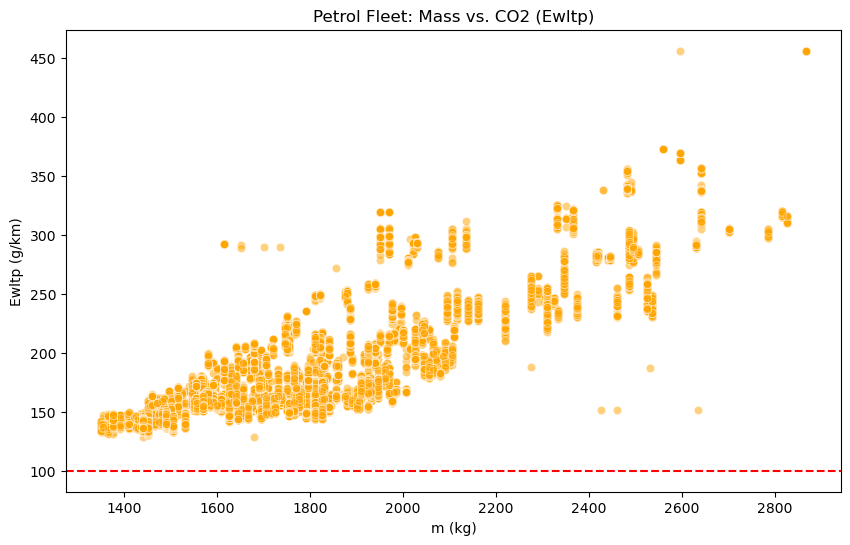

In [23]:

# focus on petrol vehicles
petrol_df = df[df['Ft'] == 'petrol'] 

print(f"Number of petrol vehicles identified: {len(petrol_df)}")

# 2. Corrected Correlation Strength

if len(petrol_df) > 1:
    correlation_p = petrol_df[['m (kg)', 'Ewltp (g/km)']].corr().iloc[0,1]
    print(f"Correlation for Petrol Vehicles: {correlation_p:.2f}")
else:
    print("Not enough petrol data")

# 3. Visualization
plt.figure(figsize=(10, 6))
sns.scatterplot(data=petrol_df, x='m (kg)', y='Ewltp (g/km)', alpha=0.5, color='orange')
plt.axhline(y=target_limit, color='red', linestyle='--', label='Euro 7 Target')
plt.title('Petrol Fleet: Mass vs. CO2 (Ewltp)')
plt.show()

In [45]:
petrol_df = df[df['Ft'] == 'petrol'] 

In [29]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
import torch.optim as optim


# 1. Prepare Petrol-Specific Data
X_p = petrol_df[['m (kg)', 'ec (cm3)']].values
y_p = petrol_df['Ewltp (g/km)'].values.reshape(-1, 1)

# Split and Scale
X_train, X_test, y_train, y_test = train_test_split(X_p, y_p, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_t = torch.tensor(scaler.fit_transform(X_train), dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32)

# 2. A slightly deeper Model for better accuracy
class Euro7Predictor(nn.Module):
    def __init__(self):
        super(Euro7Predictor, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1)
        )

    def forward(self, x):
        return self.net(x)

model = Euro7Predictor()
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.005)

# 3. Training Loop
for epoch in range(150):
    optimizer.zero_grad()
    outputs = model(X_train_t)
    loss = criterion(outputs, y_train_t)
    loss.backward()
    optimizer.step()
    
    if (epoch + 1) % 25 == 0:
        # RMSE
        rmse = torch.sqrt(loss).item()
        print(f'Epoch [{epoch+1}/150], Loss: {loss.item():.2f}, RMSE: {rmse:.2f} g/km')

Epoch [25/150], Loss: nan, RMSE: nan g/km
Epoch [50/150], Loss: nan, RMSE: nan g/km
Epoch [75/150], Loss: nan, RMSE: nan g/km
Epoch [100/150], Loss: nan, RMSE: nan g/km
Epoch [125/150], Loss: nan, RMSE: nan g/km
Epoch [150/150], Loss: nan, RMSE: nan g/km


In [47]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler



# QC to be safe
clean_petrol = petrol_df.dropna(subset=['m (kg)', 'ec (cm3)', 'Ewltp (g/km)'])

# Prepare Features (X) and Target (y)
X = clean_petrol[['m (kg)', 'ec (cm3)']].values
y = clean_petrol['Ewltp (g/km)'].values.reshape(-1, 1)

# Split into Training and Testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- 2. SCALING (The Stability Fix) ---
# Scale Features (X)
scaler_x = StandardScaler()
X_train_scaled = scaler_x.fit_transform(X_train)
X_test_scaled = scaler_x.transform(X_test)


# Scaling CO2 values (e.g. 200g) to a range near 0-1, to prevent very high gradient
scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train)
y_test_scaled = scaler_y.transform(y_test)

# Converting to PyTorch Tensors
X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_t = torch.tensor(y_train_scaled, dtype=torch.float32)
X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_t = torch.tensor(y_test_scaled, dtype=torch.float32)

# --- 3. MODEL ARCHITECTURE ---
class Euro7Predictor(nn.Module):
    def __init__(self):
        super(Euro7Predictor, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1)
        )

    def forward(self, x):
        return self.net(x)

model = Euro7Predictor()
criterion = nn.MSELoss()

# a slightly lower learning rate for smoother convergence
optimizer = optim.Adam(model.parameters(), lr=0.001)

# --- 4. TRAINING LOOP ---
print(f"Starting training on {len(X_train_t)} samples...")

epochs = 200
for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    
    # Forward pass
    outputs = model(X_train_t)
    loss = criterion(outputs, y_train_t)
    
    # Backward pass
    loss.backward()
    
    # SAFETY: Gradient Clipping 
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    
    optimizer.step()
    
    if (epoch + 1) % 25 == 0:
        # To get the Real-World RMSE, I inversed the scale of the loss
        # RMSE in scaled units
        rmse_scaled = np.sqrt(loss.item())
        # RMSE in actual g/km
        actual_rmse = rmse_scaled * np.sqrt(scaler_y.var_[0])
        
        print(f'Epoch [{epoch+1}/{epochs}] | MSE Loss: {loss.item():.4f} | Est. RMSE: {actual_rmse:.2f} g/km')

# --- 5. EVALUATION ---
model.eval()
with torch.no_grad():
    predictions_scaled = model(X_test_t)
    # Converting predictions back to original CO2 units (g/km)
    predictions = scaler_y.inverse_transform(predictions_scaled.numpy())
    
    # first 5 comparisons
    print("\n--- Sample Predictions (Actual vs Predicted) ---")
    for i in range(5):
        print(f"Actual: {y_test[i][0]:.1f} g/km | Predicted: {predictions[i][0]:.1f} g/km")

Starting training on 133991 samples...
Epoch [25/200] | MSE Loss: 0.7328 | Est. RMSE: 48.89 g/km
Epoch [50/200] | MSE Loss: 0.4035 | Est. RMSE: 36.28 g/km
Epoch [75/200] | MSE Loss: 0.1771 | Est. RMSE: 24.03 g/km
Epoch [100/200] | MSE Loss: 0.1251 | Est. RMSE: 20.20 g/km
Epoch [125/200] | MSE Loss: 0.1107 | Est. RMSE: 19.00 g/km
Epoch [150/200] | MSE Loss: 0.1054 | Est. RMSE: 18.54 g/km
Epoch [175/200] | MSE Loss: 0.1016 | Est. RMSE: 18.20 g/km
Epoch [200/200] | MSE Loss: 0.0981 | Est. RMSE: 17.89 g/km

--- Sample Predictions (Actual vs Predicted) ---
Actual: 139.0 g/km | Predicted: 142.5 g/km
Actual: 149.0 g/km | Predicted: 161.8 g/km
Actual: 150.0 g/km | Predicted: 143.0 g/km
Actual: 172.0 g/km | Predicted: 172.3 g/km
Actual: 339.0 g/km | Predicted: 318.0 g/km


In [49]:
from sklearn.metrics import mean_squared_error

model.eval()
with torch.no_grad():
    # 1. all predictions for the test set
    test_preds_scaled = model(X_test_t)
    
    # 2. Inverse transform to get back to g/km
    test_preds = scaler_y.inverse_transform(test_preds_scaled.numpy())
    
    # 3.Final RMSE
    final_rmse = np.sqrt(mean_squared_error(y_test, test_preds))
    
    # 4. MAPE (Mean Absolute Percentage Error) - Recruiters love this!
    mape = np.mean(np.abs((y_test - test_preds) / y_test)) * 100

print(f"--- Final Evaluation Metrics ---")
print(f"Test RMSE: {final_rmse:.2f} g/km")
print(f"Mean Error Rate (MAPE): {mape:.2f}%")

--- Final Evaluation Metrics ---
Test RMSE: 17.81 g/km
Mean Error Rate (MAPE): 6.30%


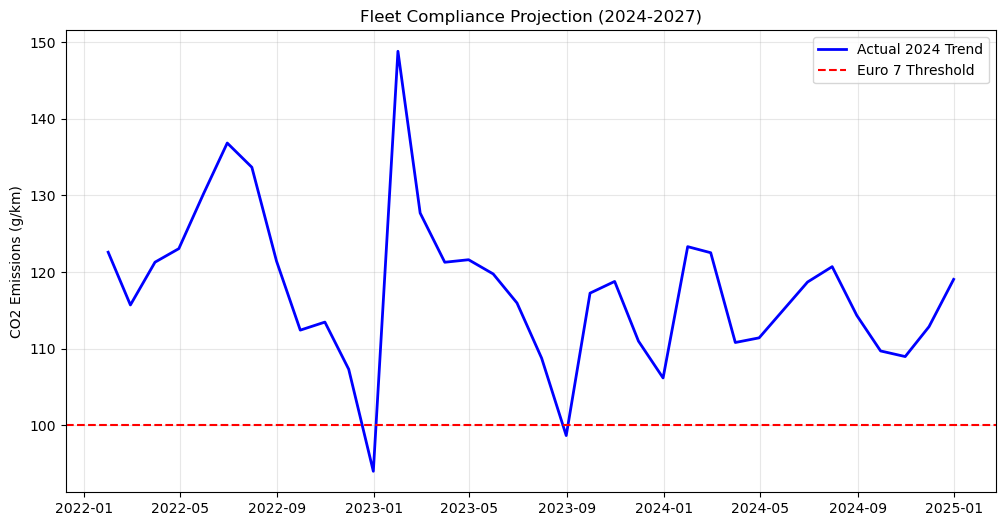

In [87]:
# 1. Grouped by registration month 
fleet_trend = df.set_index('Date of registration').resample('ME')['Ewltp (g/km)'].mean()

# 2. Linear Projection to May 2027 (Euro 7 Start)
months_passed = np.arange(len(fleet_trend))
z = np.polyfit(months_passed, fleet_trend.values, 1)
p = np.poly1d(z)

# future dates
future_months = np.arange(len(fleet_trend), len(fleet_trend) + 36)
forecast = p(future_months)


plt.figure(figsize=(12, 6))
plt.plot(fleet_trend.index, fleet_trend.values, label='Actual 2024 Trend', color='blue', linewidth=2)
plt.axhline(y=target_limit, color='red', linestyle='--', label='Euro 7 Threshold')
plt.title('Fleet Compliance Projection (2024-2027)')
plt.ylabel('CO2 Emissions (g/km)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

--- Final Portfolio Metrics ---
Test RMSE: 17.81 g/km
R² Score: 0.9043 (Accuracy measure, 1.0 is perfect)


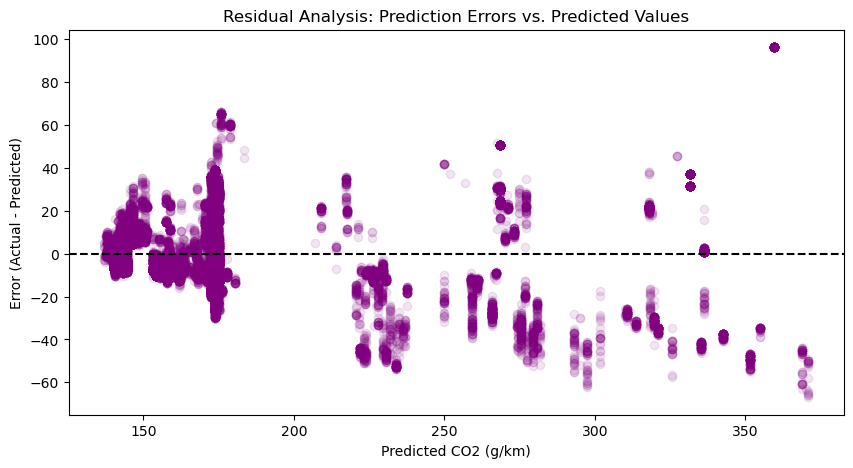

In [53]:
from sklearn.metrics import mean_squared_error, r2_score

model.eval()
with torch.no_grad():
    # 1. Get all predictions for the test set
    test_preds_scaled = model(X_test_t)
    test_preds = scaler_y.inverse_transform(test_preds_scaled.numpy())
    
    # 2. Calculate Metrics
    test_rmse = np.sqrt(mean_squared_error(y_test, test_preds))
    r2 = r2_score(y_test, test_preds)
    
    print(f"--- Final Portfolio Metrics ---")
    print(f"Test RMSE: {test_rmse:.2f} g/km")
    print(f"R² Score: {r2:.4f} (Accuracy measure, 1.0 is perfect)")

# 3. Residual Plot: Where does the model fail?
residuals = y_test - test_preds
plt.figure(figsize=(10, 5))
plt.scatter(test_preds, residuals, alpha=0.1, color='purple')
plt.axhline(y=0, color='black', linestyle='--')
plt.title('Residual Analysis: Prediction Errors vs. Predicted Values')
plt.xlabel('Predicted CO2 (g/km)')
plt.ylabel('Error (Actual - Predicted)')
plt.show()

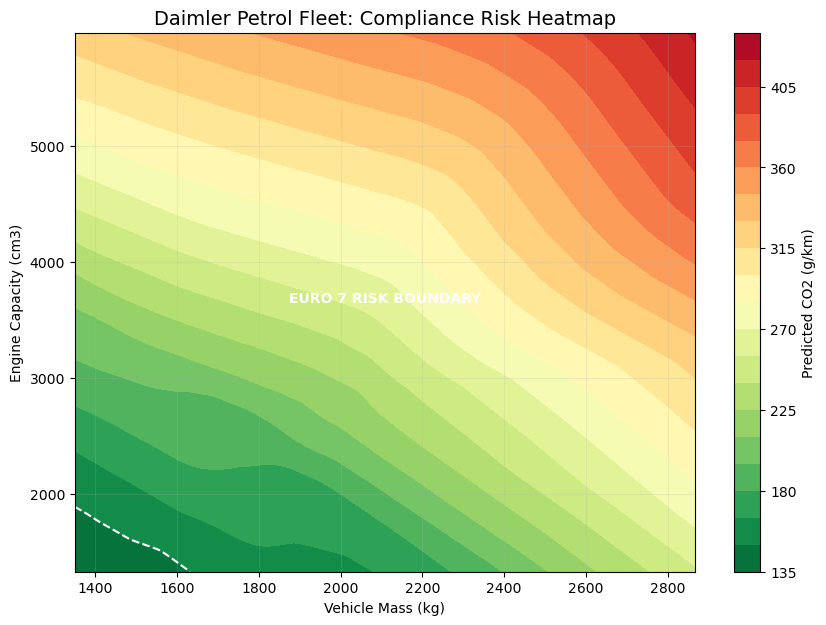

In [55]:
# Create a grid for the 'Design Space'
m_range = np.linspace(X[:,0].min(), X[:,0].max(), 100)
ec_range = np.linspace(X[:,1].min(), X[:,1].max(), 100)
M, EC = np.meshgrid(m_range, ec_range)

# Prepare grid for the model
grid_input = np.c_[M.ravel(), EC.ravel()]
grid_input_scaled = scaler_x.transform(grid_input)
grid_input_t = torch.tensor(grid_input_scaled, dtype=torch.float32)

# Predict CO2 across the entire grid
model.eval()
with torch.no_grad():
    grid_preds_scaled = model(grid_input_t)
    grid_preds = scaler_y.inverse_transform(grid_preds_scaled.numpy()).reshape(M.shape)

# Plot the 'Compliance Heatmap'
plt.figure(figsize=(10, 7))
cp = plt.contourf(M, EC, grid_preds, levels=20, cmap='RdYlGn_r') # Red-Yellow-Green (reversed)
plt.colorbar(cp, label='Predicted CO2 (g/km)')

# Add a 'Euro 7 Risk Line' (Example: 150g/km threshold)
# You can adjust this '150' based on the target_limit we calculated earlier
plt.contour(M, EC, grid_preds, levels=[150], colors='white', linestyles='dashed')
plt.text(M.mean(), EC.mean(), 'EURO 7 RISK BOUNDARY', color='white', fontweight='bold', ha='center')

plt.title('Daimler Petrol Fleet: Compliance Risk Heatmap', fontsize=14)
plt.xlabel('Vehicle Mass (kg)')
plt.ylabel('Engine Capacity (cm3)')
plt.grid(alpha=0.2)
plt.show()

In [57]:
torch.save(model.state_dict(), 'euro7_model.pth')

In [67]:

# 1. Filter for the 'Truck' Universe
# Category N2/N3 is typically > 3500kg
truck_fleet = df[df['m (kg)'] > 3500].copy()

# 2. Define Heavy-Duty Industry Constants (2026 Context)
# EU Regulation 2019/1242 & 2024 Amendments
TRUCK_CO2_TARGET_2025 = 153.9  # g/km (Representative target for N2/N3)
HDV_PENALTY_RATE = 4250        # € per g/tkm (converted to ~€190 per g/km for simplified modeling)
AVG_TRUCK_RETAIL = 200000      # 200k Euro base
PROFIT_MARGIN_2026 = 0.07      # 7% Adjusted ROS (Daimler Truck 2026 Guidance)

# 3. The "Zombie" Logic for Heavy-Duty
def truck_audit(row):
    unit_profit = AVG_TRUCK_RETAIL * PROFIT_MARGIN_2026 # ~€17,500
    
    # Calculate the deviation from the 15% reduction target
    gap = max(0, row['Ewltp (g/km)'] - TRUCK_CO2_TARGET_2025)
    
    # Financial Penalty calculation
    # Note: Trucks use g/tkm, but for this proxy we use the €190/g/km conversion
    potential_fine = gap * 190 
    
    is_zombie = potential_fine > unit_profit
    
    return pd.Series([potential_fine, is_zombie, unit_profit], 
                     index=['Penalty', 'Is_Zombie', 'Unit_Profit'])

# 4. Run the Heavy-Duty Audit
truck_fleet[['Fine', 'Is_Zombie', 'Margin']] = truck_fleet.apply(truck_audit, axis=1)

# 5. Strategic Summary for Daimler Truck
total_fine_risk = truck_fleet['Fine'].sum()
zombie_count = truck_fleet['Is_Zombie'].sum()


print(f"Total Heavy-Duty Units Analyzed: {len(truck_fleet)}")
print(f"Financial Zombie vehicles: {zombie_count}")
print(f"Total Portfolio Penalty Risk: €{total_fine_risk/1e6:.2f} Million")

# Display the "Critical 7" (or whichever are your top risk models)
print("\nTOP 5 HIGH-RISK TRUCK CONFIGURATIONS:")
print(truck_fleet[truck_fleet['Is_Zombie'] == True][['Cn', 'm (kg)', 'Ewltp (g/km)', 'Fine']].head())

Total Heavy-Duty Units Analyzed: 7
Financial Zombie vehicles: 7
Total Portfolio Penalty Risk: €0.40 Million

TOP 5 HIGH-RISK TRUCK CONFIGURATIONS:
                  Cn  m (kg)  Ewltp (g/km)     Fine
154944  S 680 4MATIC    4255         453.0  56829.0
154945  S 680 4MATIC    4255         453.0  56829.0
154946  S 680 4MATIC    4255         453.0  56829.0
154947  S 680 4MATIC    4255         453.0  56829.0
154948  S 680 4MATIC    4255         453.0  56829.0


In [71]:
import pandas as pd

# 1. Updating Parameters for 2026 Mercedes-Benz Guidance
TARGET_2026 = 93.6
PENALTY_RATE = 95
RETAIL_PRICE = 55000
MARGIN_2026 = 0.08 # 

# 2. Calculatinge Financial Impact
def car_audit(row):
    profit = RETAIL_PRICE * MARGIN_2026 # ~€2,200
    gap = max(0, row['Ewltp (g/km)'] - TARGET_2026)
    fine = gap * PENALTY_RATE
    
    # Financial Zombie = Fine > Profit
    # Compliance Risk = Fine > 50% of Profit
    is_zombie = fine > profit
    is_high_risk = fine > (profit * 0.5)
    
    return pd.Series([fine, is_zombie, is_high_risk], 
                     index=['Fine', 'Is_Zombie', 'High_Risk'])

# 3. Analysing the Car Fleet
petrol_df[['Fine', 'Is_Zombie', 'High_Risk']] = petrol_df.apply(car_audit, axis=1)

# 4. Summary Output
total_zombies = df['Is_Zombie'].sum()
high_risk_pct = (df['High_Risk'].sum() / len(df)) * 100

print(f"--- MERCEDES-BENZ STRATEGIC CAR AUDIT (2026) ---")
print(f"Total Portfolio Fines: €{df['Fine'].sum()/1e6:.2f} Million")
print(f"Financial Zombie Models: {total_zombies}")
print(f"Portfolio at High Risk (>50% margin loss): {high_risk_pct:.1f}%")

--- MERCEDES-BENZ STRATEGIC CAR AUDIT (2026) ---
Total Portfolio Fines: €3873.94 Million
Financial Zombie Models: 375996
Portfolio at High Risk (>50% margin loss): 65.2%
